In [1]:
import numpy as np
import matplotlib.pyplot as plt

from candel import load_config
from candel.pvdata import CepheidData, to_mwcepheids_config
import scienceplots  # noqa

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
config = to_mwcepheids_config(load_config("../scripts/config.toml", replace_los_prior=False))
config["data"]

2026-05-07 14:51:27 ============================================================
2026-05-07 14:51:27 Model Configuration
2026-05-07 14:51:27 ============================================================
2026-05-07 14:51:27   Model type      : forward
2026-05-07 14:51:27   Distance prior  : disk
2026-05-07 14:51:27   Scatter         : per-campaign
2026-05-07 14:51:27   Q index         : disabled
2026-05-07 14:51:27   Spiral arms     : disabled
2026-05-07 14:51:27 ------------------------------------------------------------
2026-05-07 14:51:27 C22 Selection
2026-05-07 14:51:27 ------------------------------------------------------------
2026-05-07 14:51:27   mW selection    : ENABLED
2026-05-07 14:51:27   mW_max          : infer
2026-05-07 14:51:27   mW_width        : 0.500
2026-05-07 14:51:27   AH selection    : disabled
2026-05-07 14:51:27   pi selection    : ENABLED
2026-05-07 14:51:27   pi_min          : infer
2026-05-07 14:51:27   pi_smooth       : True
2026-05-07 14:51:27   pi_width

2026-05-07 14:51:27 ============================================================


{'R21_MW': '/mnt/users/rstiskalek/CANDEL/data/Riess2021_Table1_with_coords.csv',
 'exclude_stars': ['S-VUL', 'SV-VUL'],
 'C22': {'pi_cut': 0.0},
 'C27': {'pi_cut': 0.79},
 'anchors': {'NGC4258': {'csv': '/mnt/users/rstiskalek/CANDEL/data/SH0ES_N4258_Cepheids.csv',
   'covmat': '/mnt/users/rstiskalek/CANDEL/data/SH0ES_N4258_covmat.npy',
   'mu': 29.398,
   'e_mu': 0.032,
   'logP_min': -0.3},
  'LMC': {'csv': '/mnt/users/rstiskalek/CANDEL/data/SH0ES_LMC_Cepheids.csv',
   'covmat': '/mnt/users/rstiskalek/CANDEL/data/SH0ES_LMC_covmat.npy',
   'mu': 18.477,
   'e_mu': 0.0263,
   'logP_min': -0.3,
   'hst_only': True}}}

In [3]:
data = CepheidData(config)
print(data)

2026-05-07 14:51:27 Dropping 7 stars without EDR3: CY-AUR, DL-CAS, RW-CAM, SV-PER, SY-NOR, RX-CAM, U-AQL
2026-05-07 14:51:27 Loaded 67 stars from /mnt/users/rstiskalek/CANDEL/data/Riess2021_Table1_with_coords.csv
2026-05-07 14:51:27 Excluding 2 stars: S-VUL, SV-VUL
2026-05-07 14:51:27 C22 pi > 0.0: 42/42 C22 stars kept
2026-05-07 14:51:27 C27 pi > 0.79: 22/23 C27 stars kept
2026-05-07 14:51:28 Final sample: 64 stars (42 C22 + 22 C27)
CepheidData(64 stars: 42 C22 + 22 C27)


In [4]:
import jax.numpy as jnp

cols = config["plotting"]["colours"]

cycles = [
    {"mask": data.is_c22, "label": "Cycle 22", "fmt": "o", "color": cols[0]},
    {"mask": data.is_c27, "label": "Cycle 27", "fmt": "s", "color": cols[2]},
]


def hist_by_cycle(ax, values, xlabel, density=False):
    """Plot stepped histograms split by observing cycle."""
    for c in cycles:
        m = np.asarray(c["mask"])
        ax.hist(np.asarray(values)[m], bins="auto", histtype="step",
                density=density, label=c["label"], color=c["color"])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density" if density else "Counts per bin")
    ax.legend()

## Period--Luminosity relation in the Wesenheit magnitude

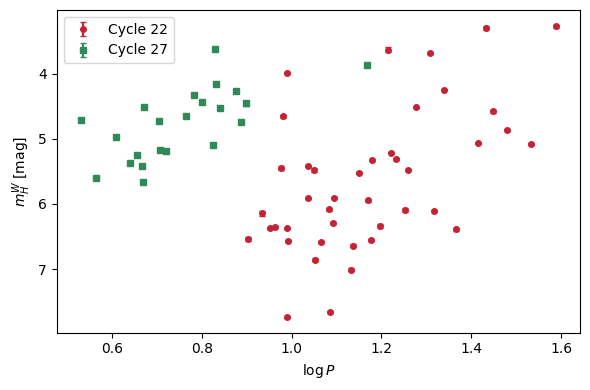

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for c in cycles:
    m = np.asarray(c["mask"])
    ax.errorbar(np.asarray(data.logP)[m], np.asarray(data.mW_H)[m],
                yerr=np.asarray(data.mW_H_err)[m],
                fmt=c["fmt"], ms=4, label=c["label"], capsize=2,
                color=c["color"])
ax.set_xlabel(r"$\log P$")
ax.set_ylabel(r"$m^W_H$ [mag]")
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
plt.show()

## Gaia EDR3 parallax distribution

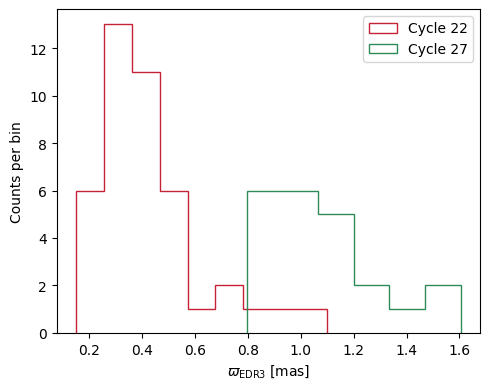

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
hist_by_cycle(ax, data.pi_EDR3, r"$\varpi_\mathrm{EDR3}\;[\mathrm{mas}]$")
fig.tight_layout()
plt.show()

## Metallicity, period, and parallax distributions

In [32]:
from tqdm.auto import trange

delta_pi = -0.01
disk_cfg = config["model"]["disk_prior"]
mc_cfg = config["model"].get("selection_mc", {})
rng_disk = np.random.default_rng(12345)


def thin_disk_draws(pi_lo, pi_hi, n_ref=10_000_000,
                    batch_size=5_000_000, max_batches=10000,
                    desc="thin disk MC"):
    d_min = 1.0 / (pi_hi + delta_pi)
    d_max = 1.0 / (pi_lo + delta_pi)
    sin_b_min = np.sin(np.deg2rad(mc_cfg.get("b_min", -15.0)))
    sin_b_max = np.sin(np.deg2rad(mc_cfg.get("b_max", 15.0)))
    pi_ref = []
    n_accept = 0

    for _ in trange(max_batches, desc=desc, leave=False):
        ell = rng_disk.uniform(mc_cfg.get("ell_min", 0.0),
                               mc_cfg.get("ell_max", 360.0),
                               batch_size)
        sin_b = rng_disk.uniform(sin_b_min, sin_b_max, batch_size)
        b_r = np.arcsin(sin_b)
        u = rng_disk.uniform(size=batch_size)
        d = (d_min**3 + u * (d_max**3 - d_min**3))**(1.0 / 3.0)

        ell_r = np.deg2rad(ell)
        x = d * np.cos(b_r) * np.cos(ell_r)
        y = d * np.cos(b_r) * np.sin(ell_r)
        z = d * sin_b
        R_gc = np.sqrt((disk_cfg.get("R_sun", 8.122) - x)**2 + y**2)
        log_accept = (-R_gc / disk_cfg.get("R_d", 2.5)
                      - np.abs(z) / disk_cfg.get("z_d", 0.1))
        accept = np.log(rng_disk.uniform(size=batch_size)) < log_accept
        if np.any(accept):
            pi_ref.append(1.0 / d[accept] - delta_pi)
            n_accept += int(np.sum(accept))
        if n_accept >= n_ref:
            break

    if n_accept < n_ref:
        raise RuntimeError(f"Only accepted {n_accept} thin-disk samples.")

    return np.concatenate(pi_ref)[:n_ref]


thin_disk_draws_by_cycle = {}
for cyc in cycles:
    m = np.asarray(cyc["mask"])
    pi_obs_c = np.asarray(data.pi_EDR3)[m]
    pi_lo, pi_hi = pi_obs_c.min(), pi_obs_c.max()
    thin_disk_draws_by_cycle[cyc["label"]] = thin_disk_draws(
        pi_lo, pi_hi, desc=f"thin disk {cyc['label']}")

thin disk Cycle 22:   0%|          | 0/10000 [00:00<?, ?it/s]

thin disk Cycle 27:   0%|          | 0/10000 [00:00<?, ?it/s]

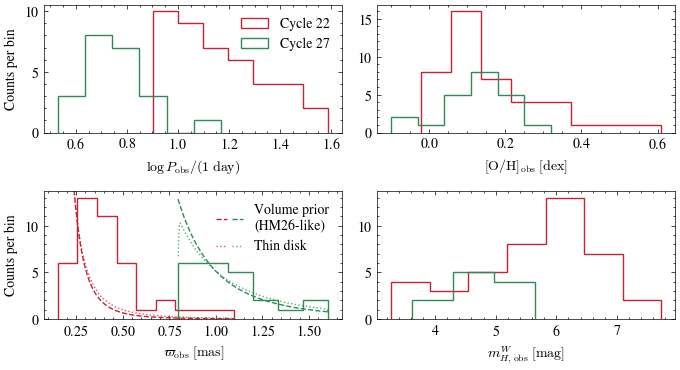

In [34]:
with plt.style.context(['science', 'no-latex']):
    fig, axes = plt.subplots(2, 2, figsize=(7, 3.9))

    hist_by_cycle(axes[0, 0], data.logP, r"$\log P_{\rm obs} / (1\;\mathrm{day})$")
    hist_by_cycle(axes[0, 1], data.OH, r"$[{\rm O/H}]_{\rm obs}\;[\mathrm{dex}]$")
    hist_by_cycle(axes[1, 0], data.pi_EDR3, r"$\varpi_{\rm obs}\;[\mathrm{mas}]$")
    hist_by_cycle(axes[1, 1], data.mW_H, r"$m^W_{H,\,\rm obs}\;[\mathrm{mag}]$")
    ax_pi = axes[1, 0]
    pi_hist_ylim = ax_pi.get_ylim()

    # Overlay analytical d^2 prior parallax PDF on parallax panel.
    # pi_obs = 1/d - delta_pi, d ~ d^2 on [d_min, d_max]
    # => p(pi_obs) = 3 / [(d_max^3 - d_min^3)
    #                    * (pi_obs + delta_pi)^4]
    smooth_sigma_bins = 1.5
    smooth_radius = int(np.ceil(4 * smooth_sigma_bins))
    smooth_x = np.arange(-smooth_radius, smooth_radius + 1)
    smooth_kernel = np.exp(-0.5 * (smooth_x / smooth_sigma_bins)**2)
    smooth_kernel /= smooth_kernel.sum()

    for cyc in cycles:
        m = np.asarray(cyc["mask"])
        pi_obs_c = np.asarray(data.pi_EDR3)[m]
        obs_counts, obs_edges = np.histogram(pi_obs_c, bins="auto")
        obs_area = np.sum(obs_counts * np.diff(obs_edges))
        pi_lo, pi_hi = pi_obs_c.min(), pi_obs_c.max()
        pi_grid = np.linspace(pi_lo, pi_hi, 300)
        pdf = 1.0 / (pi_grid + delta_pi)**4
        pdf /= np.trapezoid(pdf, pi_grid)
        expected_counts = pdf * obs_area
        ax_pi.plot(pi_grid, expected_counts, color=cyc["color"],
                   ls="--", lw=1.0)

        disk_pi = thin_disk_draws_by_cycle[cyc["label"]]
        disk_counts, disk_edges = np.histogram(disk_pi, bins="auto",
                                               range=(pi_lo, pi_hi))
        disk_centres = 0.5 * (disk_edges[:-1] + disk_edges[1:])
        disk_counts = np.convolve(disk_counts.astype(float),
                                  smooth_kernel, mode="same")
        disk_area = np.trapezoid(disk_counts, disk_centres)
        disk_counts = disk_counts * obs_area / disk_area
        ax_pi.plot(disk_centres, disk_counts, color=cyc["color"],
                   ls=":", lw=1.0, alpha=0.75)

    ax_pi.set_ylabel("Counts per bin")
    ax_pi.set_ylim(pi_hist_ylim)

    for ax in axes.ravel():
        ax.legend().remove()
    axes[0, 0].legend(frameon=False)
    # Show one entry per reference curve style.
    from matplotlib.legend_handler import HandlerTuple
    from matplotlib.lines import Line2D
    volume_handle = (
        Line2D([], [], color=cycles[0]["color"], ls="--", lw=1.0),
        Line2D([], [], color=cycles[1]["color"], ls="--", lw=1.0),
    )
    disk_handle = (
        Line2D([], [], color=cycles[0]["color"], ls=":", lw=1.0,
               alpha=0.75),
        Line2D([], [], color=cycles[1]["color"], ls=":", lw=1.0,
               alpha=0.75),
    )
    ax_pi.legend([volume_handle, disk_handle],
                 ["Volume prior\n(HM26-like)", "Thin disk"],
                 handler_map={tuple: HandlerTuple(ndivide=None)},
                 frameon=False, loc="upper right")
    axes[0, 1].set_ylabel("")
    axes[1, 1].set_ylabel("")

    fig.tight_layout()
    fig.savefig("../plots/data_distributions.pdf", bbox_inches="tight")
    plt.show()

## HST photometry: colour-magnitude diagram

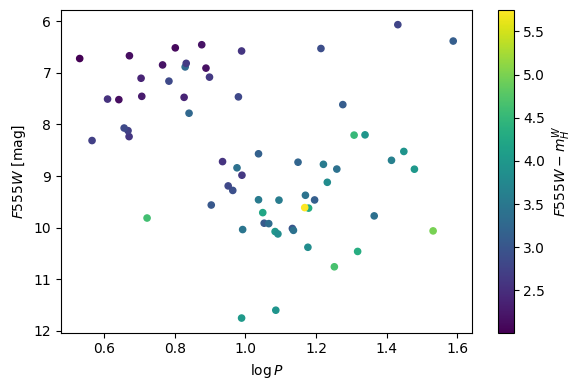

In [8]:
colour = np.asarray(data.F555W) - np.asarray(data.mW_H)

fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(np.asarray(data.logP), np.asarray(data.F555W),
                c=colour, s=20, cmap="viridis")
ax.set_xlabel(r"$\log P$")
ax.set_ylabel(r"$F555W$ [mag]")
ax.invert_yaxis()
fig.colorbar(sc, ax=ax, label=r"$F555W - m^W_H$")
fig.tight_layout()
plt.show()

## Naive distance estimates from EDR3 parallaxes

Simple inversion $d\,[\mathrm{kpc}] = 1 / \varpi\,[\mathrm{mas}]$. Note this is biased when $\sigma_\varpi / \varpi$ is large.

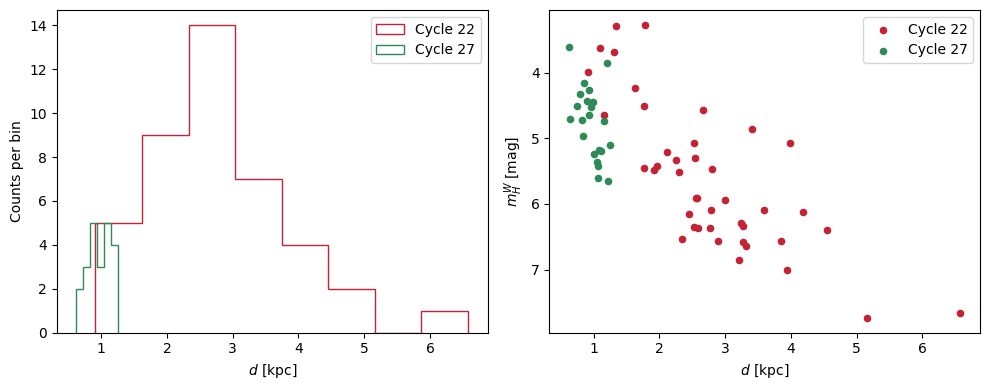

In [9]:
d_kpc = 1.0 / np.asarray(data.pi_EDR3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

hist_by_cycle(axes[0], jnp.array(d_kpc), r"$d$ [kpc]")

for c in cycles:
    m = np.asarray(c["mask"])
    axes[1].scatter(d_kpc[m], np.asarray(data.mW_H)[m], s=20,
                    label=c["label"], color=c["color"])
axes[1].set_xlabel(r"$d$ [kpc]")
axes[1].set_ylabel(r"$m^W_H$ [mag]")
axes[1].invert_yaxis()
axes[1].legend()

fig.tight_layout()
plt.show()

## C22 magnitude distribution by Galactic latitude

In [10]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Get C22 mask and data
is_c22 = np.asarray(data.is_c22)
names_c22 = data.names[is_c22]
mW_c22 = np.asarray(data.mW_H)[is_c22]

# Resolve Galactic coordinates from SIMBAD using star names
ell_c22 = np.zeros(len(names_c22))
b_c22 = np.zeros(len(names_c22))
for i, name in enumerate(names_c22):
    simbad_name = name.replace("-", " ")
    coord = SkyCoord.from_name(simbad_name)
    ell_c22[i] = coord.galactic.l.deg
    b_c22[i] = coord.galactic.b.deg

print(f"ell range: {ell_c22.min():.1f} to {ell_c22.max():.1f} deg")
print(f"b range: {b_c22.min():.1f} to {b_c22.max():.1f} deg")

ell range: 12.1 to 356.5 deg
b range: -7.1 to 5.9 deg


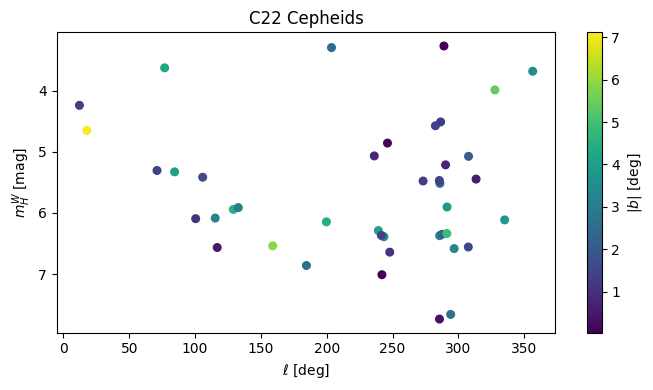

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(ell_c22, mW_c22, c=np.abs(b_c22), s=30, cmap="viridis")
ax.set_xlabel(r"$\ell$ [deg]")
ax.set_ylabel(r"$m^W_H$ [mag]")
ax.set_title("C22 Cepheids")
ax.invert_yaxis()
fig.colorbar(sc, ax=ax, label=r"$|b|$ [deg]")
fig.tight_layout()
plt.show()